In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#234567890
using DataFrames
using Pipe
using PyPlot
using Random
using Statistics

In [2]:
function sim_e()
    draw = Float64[]
    while true
        push!(draw, rand())
        sum(draw) > 1.0 && return draw
    end
end

sim_e (generic function with 1 method)

In [3]:
Random.seed!(4321);

In [4]:
res = [sim_e() for _ in 1:5]

5-element Vector{Vector{Float64}}:
 [0.549646602186891, 0.1295805209303995, 0.8647701448945764]
 [0.048563077743689065, 0.10271005862089821, 0.4011373724024988, 0.7440394139194013]
 [0.8323080594185164, 0.13083238137887598, 0.36406839362517673]
 [0.006071525002571687, 0.526382759960887, 0.6666411661708421]
 [0.0036467654234990654, 0.6273931086515868, 0.48479966793423024]

In [5]:
sum.(res)

5-element Vector{Float64}:
 1.543997268011867
 1.2964499226864874
 1.327208834422569
 1.1990954511343008
 1.1158395420093161

In [8]:
@. sum(res) - last(res)

5-element Vector{Float64}:
 0.6792271231172906
 0.5524105087670861
 0.9631404407973922
 0.5324542849634587
 0.6310398740750859

In [9]:
df = DataFrame()
@time for i in 1:10^7
    push!(df, (id=i, pos=sim_e()))
end

  6.348295 seconds (122.07 M allocations: 3.609 GiB, 49.87% gc time, 2.34% compilation time)


In [10]:
first(df, 5)

Row,id,pos
,Int64,Array…
1,1,"[0.703448, 0.601163]"
2,2,"[0.556119, 0.54078]"
3,3,"[0.471596, 0.231989, 0.828495]"
4,4,"[0.298317, 0.721462]"
5,5,"[0.631869, 0.632048]"


In [11]:
transform!(df, :pos => ByRow(length) => :nsamples)

Row,id,pos,nsamples
,Int64,Array…,Int64
1,1,"[0.703448, 0.601163]",2
2,2,"[0.556119, 0.54078]",2
3,3,"[0.471596, 0.231989, 0.828495]",3
4,4,"[0.298317, 0.721462]",2
5,5,"[0.631869, 0.632048]",2
6,6,"[0.841703, 0.936391]",2
7,7,"[0.404483, 0.388867, 0.0911069, 0.446397]",4
8,8,"[0.570463, 0.33979, 0.422048]",3
9,9,"[0.546684, 0.0413326, 0.470278]",3


In [12]:
mean(df.nsamples)

2.718648

In [13]:
combine(df, :nsamples => mean)

Row,nsamples_mean
,Float64
1,2.71865


In [14]:
MathConstants.e

ℯ = 2.7182818284590...

In [15]:
samps_agg = @pipe df |>
    groupby(_, :nsamples, sort=true) |>
    combine(_, :nsamples => length)

Row,nsamples,nsamples_length
,Int64,Int64
1,2,4998067
2,3,3334286
3,4,1250488
4,5,333741
5,6,69397
6,7,12009
7,8,1748
8,9,242
9,10,18


In [16]:
transform!(
    samps_agg,
    :nsamples_length => (x -> x ./ sum(x)) => :simulation,
    :nsamples => ByRow(x -> (x - 1) / factorial(x)) => :theory)

Row,nsamples,nsamples_length,simulation,theory
,Int64,Int64,Float64,Float64
1,2,4998067,0.499807,0.5
2,3,3334286,0.333429,0.333333
3,4,1250488,0.125049,0.125
4,5,333741,0.0333741,0.0333333
5,6,69397,0.0069397,0.00694444
6,7,12009,0.0012009,0.00119048
7,8,1748,0.0001748,0.000173611
8,9,242,2.42e-5,2.20459e-5
9,10,18,1.8e-6,2.48016e-6


In [17]:
first(df, 5)

Row,id,pos,nsamples
,Int64,Array…,Int64
1,1,"[0.703448, 0.601163]",2
2,2,"[0.556119, 0.54078]",2
3,3,"[0.471596, 0.231989, 0.828495]",3
4,4,"[0.298317, 0.721462]",2
5,5,"[0.631869, 0.632048]",2


In [18]:
dftest = select(
    df, :pos => ByRow(first) => :first, :pos => ByRow(last) => :last)

Row,first,last
,Float64,Float64
1,0.703448,0.601163
2,0.556119,0.54078
3,0.471596,0.828495
4,0.298317,0.721462
5,0.631869,0.632048
6,0.841703,0.936391
7,0.404483,0.446397
8,0.570463,0.422048
9,0.546684,0.470278


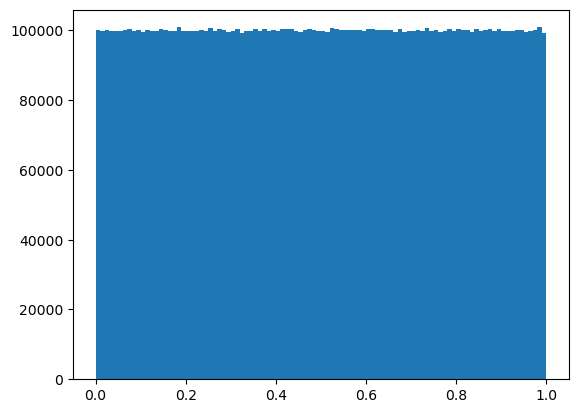

In [19]:
hist(dftest.first, 100);

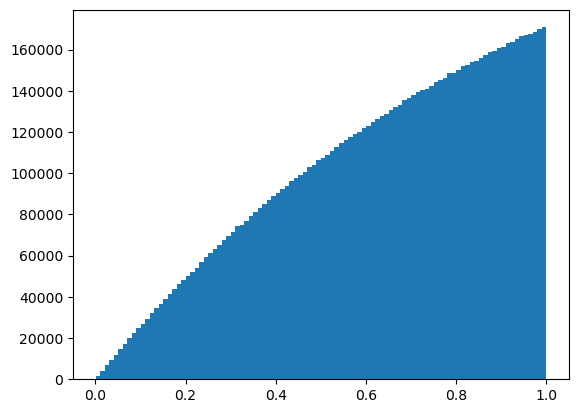

In [20]:
hist(dftest.last, 100);